# FDAX Local Pivot Point Conditional Probabilities (v2 - Full Range)
## First Hour (9:00-10:00) Derived Pivot Points - ALL Targets for Every Condition

**Difference from v1:** v1 showed only 6 up + 6 down targets per condition.
This version shows the FULL range of all 25 target levels for every condition,
giving complete visibility into probability decay across the entire price ladder.

**Methodology (unchanged from v1):**
1. Calculate first hour range (9:00-9:55) High/Low/Close
2. Derive local pivots using standard formulas (LPP, LR1-3, LS1-3 + fractionals)
3. Classify opening zone at 10:00
4. Track FIRST touch timestamps for 10:00-17:30 session
5. P(Target | Condition, Zone) with temporal ordering (target_ts >= condition_ts)
6. **NO TEMPORAL BIAS** - pivots from first hour, analysis from second hour onwards

**Data:** FDAX M5 OHLCV from Databento (local CSV), ~220 trading days (Mar 2025 - Jan 2026)

---

## Step 1: Setup and Data Loading

In [1]:
import sys
sys.path.insert(0, '../../')

from shared.data_module import load_from_csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (22, 16)

print('[OK] Dependencies loaded')
print('='*80)

[OK] Dependencies loaded


## Step 2: Load FDAX M5 Data from CSV

In [2]:
print('\n[STEP 2] Load FDAX M5 Data from CSV')
print('='*80)

df_m5 = load_from_csv('shared/FDAX_M5_OHLCV.csv', timezone='Europe/Berlin')

print(f'[OK] Loaded {len(df_m5)} M5 candles')
print(f'Date range: {df_m5.index.min()} to {df_m5.index.max()}')
print(f'Timezone: {df_m5.index.tz}')

df_m5['date'] = df_m5.index.date
df_m5['hour'] = df_m5.index.hour
df_m5['minute'] = df_m5.index.minute
df_m5['time'] = df_m5.index.time

# Filter to RTH (09:00-17:30)
df_m5_rth = df_m5[
    (df_m5['hour'] >= 9) & 
    ((df_m5['hour'] < 17) | ((df_m5['hour'] == 17) & (df_m5['minute'] <= 30)))
].copy()

n_days = df_m5_rth['date'].nunique()
print(f'\n[OK] RTH filtered (09:00-17:30): {len(df_m5_rth)} candles')
print(f'Trading days: {n_days}')
print(f'Date range: {df_m5_rth.index.min().date()} to {df_m5_rth.index.max().date()}')

2026-02-07 19:06:28,756 - shared.data_module - INFO - Loading data from CSV: FDAX_M5_OHLCV.csv
2026-02-07 19:06:28,802 - shared.data_module - INFO - Using timestamp column: 'candle_open'



[STEP 2] Load FDAX M5 Data from CSV


2026-02-07 19:06:28,992 - shared.data_module - INFO - Converted to timezone: Europe/Berlin
2026-02-07 19:06:28,995 - shared.data_module - INFO - [OK] Loaded 50390 candles from FDAX_M5_OHLCV.csv, range 2025-03-10 09:00:00+01:00 to 2026-01-21 22:00:00+01:00


[OK] Loaded 50390 M5 candles
Date range: 2025-03-10 09:00:00+01:00 to 2026-01-21 22:00:00+01:00
Timezone: Europe/Berlin

[OK] RTH filtered (09:00-17:30): 22660 candles
Trading days: 220
Date range: 2025-03-10 to 2026-01-21


## Step 3: Calculate Local Pivot Points from First Hour (9:00-10:00)

In [3]:
print('\n[STEP 3] Calculate Local Pivot Points (First Hour 9:00-10:00)')
print('='*80)

df_first_hour = df_m5_rth[
    (df_m5_rth['hour'] == 9) & (df_m5_rth['minute'] < 60)
].copy()

print(f'[OK] Extracted first hour candles (9:00-9:55): {len(df_first_hour)} bars')

daily_data = []

for date, day_bars in df_first_hour.groupby('date'):
    if len(day_bars) < 10:
        continue
    
    H = day_bars['high'].max()
    L = day_bars['low'].min()
    C = day_bars.iloc[-1]['close']
    
    LPP = (H + L + C) / 3
    LR1 = (2 * LPP) - L
    LS1 = (2 * LPP) - H
    LR2 = LPP + (H - L)
    LS2 = LPP - (H - L)
    LR3 = H + 2 * (LPP - L)
    LS3 = L - 2 * (H - LPP)
    
    daily_data.append({
        'date': date,
        'first_hour_high': H,
        'first_hour_low': L,
        'first_hour_close': C,
        'LPP': LPP, 'LR1': LR1, 'LS1': LS1,
        'LR2': LR2, 'LS2': LS2, 'LR3': LR3, 'LS3': LS3,
    })

df_daily = pd.DataFrame(daily_data)
print(f'[OK] Calculated local pivots for {len(df_daily)} trading days')
print(f'\nSample (first 3 days):')
print(df_daily[['date', 'first_hour_high', 'first_hour_low', 'LPP', 'LR1', 'LS1']].head(3))


[STEP 3] Calculate Local Pivot Points (First Hour 9:00-10:00)
[OK] Extracted first hour candles (9:00-9:55): 2640 bars
[OK] Calculated local pivots for 220 trading days

Sample (first 3 days):
         date  first_hour_high  first_hour_low           LPP           LR1  \
0  2025-03-10          23199.0         22764.0  22917.000000  23070.000000   
1  2025-03-11          22815.0         22650.0  22753.666667  22857.333333   
2  2025-03-12          22647.0         22480.0  22587.333333  22694.666667   

            LS1  
0  22635.000000  
1  22692.333333  
2  22527.666667  


## Step 4: Get 10:00 Price and Classify Opening Zone

In [4]:
print('\n[STEP 4] Get 10:00 Price and Classify Opening Zone')
print('='*80)

df_10am = df_m5_rth[
    (df_m5_rth['hour'] == 10) & (df_m5_rth['minute'] == 0)
][['date', 'open', 'high', 'low', 'close']].copy()

df_10am = df_10am.rename(columns={
    'open': 'price_10am', 'high': 'high_10am',
    'low': 'low_10am', 'close': 'close_10am'
})

df_daily = df_daily.merge(df_10am, on='date', how='left')
df_daily = df_daily[df_daily['price_10am'].notna()].reset_index(drop=True)

print(f'[OK] Merged 10:00 prices: {len(df_daily)} valid days')

def classify_local_zone(row):
    price = row['price_10am']
    if price > row['LR3']:     return 'Above_LR3'
    elif price > row['LR2']:   return 'LR2_LR3'
    elif price > row['LR1']:   return 'LR1_LR2'
    elif price > row['LPP']:   return 'LPP_LR1'
    elif price > row['LS1']:   return 'LS1_LPP'
    elif price > row['LS2']:   return 'LS2_LS1'
    elif price > row['LS3']:   return 'LS3_LS2'
    else:                      return 'Below_LS3'

df_daily['opening_zone'] = df_daily.apply(classify_local_zone, axis=1)

print(f'\nZone distribution:')
for zone, count in df_daily['opening_zone'].value_counts().items():
    pct = count / len(df_daily) * 100
    flag = ' [LOW N]' if count < 30 else ''
    print(f'  {zone:12} {count:4d} days ({pct:5.1f}%){flag}')


[STEP 4] Get 10:00 Price and Classify Opening Zone
[OK] Merged 10:00 prices: 220 valid days

Zone distribution:
  LPP_LR1       118 days ( 53.6%)
  LS1_LPP       102 days ( 46.4%)


## Step 5: Define ALL Local Target Levels (25 levels)

In [5]:
print('\n[STEP 5] Define Local Target Levels (25 levels per day)')
print('='*80)

# Ordered from lowest to highest - this is the spatial ordering
LEVEL_ORDER = [
    'LS3',
    'LS2_LS3_025', 'LS2_LS3_050', 'LS2_LS3_075',
    'LS2',
    'LS1_LS2_025', 'LS1_LS2_050', 'LS1_LS2_075',
    'LS1',
    'LS1_LPP_025', 'LS1_LPP_050', 'LS1_LPP_075',
    'LPP',
    'LPP_LR1_025', 'LPP_LR1_050', 'LPP_LR1_075',
    'LR1',
    'LR1_LR2_025', 'LR1_LR2_050', 'LR1_LR2_075',
    'LR2',
    'LR2_LR3_025', 'LR2_LR3_050', 'LR2_LR3_075',
    'LR3',
]

def calculate_local_targets(row):
    targets = {}
    targets['LS3'] = row['LS3']
    targets['LS2'] = row['LS2']
    targets['LS1'] = row['LS1']
    targets['LPP'] = row['LPP']
    targets['LR1'] = row['LR1']
    targets['LR2'] = row['LR2']
    targets['LR3'] = row['LR3']
    
    for lo, hi in [('LS3','LS2'), ('LS2','LS1'), ('LS1','LPP'), ('LPP','LR1'), ('LR1','LR2'), ('LR2','LR3')]:
        dist = row[hi] - row[lo]
        # Naming: range between lo and hi
        if lo == 'LS3': prefix = 'LS2_LS3'
        elif lo == 'LS2': prefix = 'LS1_LS2'
        elif lo == 'LS1': prefix = 'LS1_LPP'
        elif lo == 'LPP': prefix = 'LPP_LR1'
        elif lo == 'LR1': prefix = 'LR1_LR2'
        elif lo == 'LR2': prefix = 'LR2_LR3'
        targets[f'{prefix}_025'] = row[lo] + 0.25 * dist
        targets[f'{prefix}_050'] = row[lo] + 0.50 * dist
        targets[f'{prefix}_075'] = row[lo] + 0.75 * dist
    
    return targets

df_daily['targets'] = df_daily.apply(calculate_local_targets, axis=1)

print(f'[OK] {len(df_daily.iloc[0]["targets"])} target levels per day')
print(f'\nLevel order (low -> high):')
for i, lvl in enumerate(LEVEL_ORDER):
    val = df_daily.iloc[0]['targets'][lvl]
    print(f'  {i+1:2d}. {lvl:18} = {val:>10.1f}')


[STEP 5] Define Local Target Levels (25 levels per day)
[OK] 25 target levels per day

Level order (low -> high):
   1. LS3                =    22200.0
   2. LS2_LS3_025        =    22270.5
   3. LS2_LS3_050        =    22341.0
   4. LS2_LS3_075        =    22411.5
   5. LS2                =    22482.0
   6. LS1_LS2_025        =    22520.2
   7. LS1_LS2_050        =    22558.5
   8. LS1_LS2_075        =    22596.8
   9. LS1                =    22635.0
  10. LS1_LPP_025        =    22705.5
  11. LS1_LPP_050        =    22776.0
  12. LS1_LPP_075        =    22846.5
  13. LPP                =    22917.0
  14. LPP_LR1_025        =    22955.2
  15. LPP_LR1_050        =    22993.5
  16. LPP_LR1_075        =    23031.8
  17. LR1                =    23070.0
  18. LR1_LR2_025        =    23140.5
  19. LR1_LR2_050        =    23211.0
  20. LR1_LR2_075        =    23281.5
  21. LR2                =    23352.0
  22. LR2_LR3_025        =    23390.2
  23. LR2_LR3_050        =    23428.5
  24. LR2_L

## Step 6: Track FIRST Touch Timestamps (10:00-17:30 Session)

We only analyze 10:00-17:30 (after local pivots are established).
For each level, we record the FIRST M5 bar where the bar's [low, high]
range contains the target price.

In [6]:
print('\n[STEP 6] Track First Touch Timestamps (10:00-17:30 Session)')
print('='*80)
print('\n[WARNING] Processing intrabar data - may take 1-2 minutes...')

df_m5_session = df_m5_rth[
    (df_m5_rth['hour'] >= 10)
].copy()

print(f'[OK] Session data filtered: {len(df_m5_session)} M5 bars (10:00-17:30)')

def track_first_touches_session(date, targets_dict, df_m5_day):
    first_touches = {key: None for key in targets_dict.keys()}
    
    for timestamp, bar in df_m5_day.iterrows():
        bar_high = bar['high']
        bar_low = bar['low']
        
        for target_name, target_price in targets_dict.items():
            if first_touches[target_name] is not None:
                continue
            if bar_low <= target_price <= bar_high:
                first_touches[target_name] = timestamp
    
    return first_touches

first_touch_data = []

for idx, day_row in df_daily.iterrows():
    date = day_row['date']
    targets_dict = day_row['targets']
    
    df_m5_day = df_m5_session[df_m5_session['date'] == date].copy()
    
    if len(df_m5_day) < 10:
        continue
    
    first_touches = track_first_touches_session(date, targets_dict, df_m5_day)
    first_touch_data.append({'date': date, 'first_touches': first_touches})
    
    if (idx + 1) % 50 == 0:
        print(f'  Processed {idx + 1}/{len(df_daily)} days...')

df_touch = pd.DataFrame(first_touch_data)
df_daily = df_daily.merge(df_touch, on='date', how='left')

print(f'\n[OK] First touch timestamps tracked for {len(df_daily)} days')
print('[CONFIRMED] Temporal bias eliminated - only 10:00-17:30 analyzed')


[STEP 6] Track First Touch Timestamps (10:00-17:30 Session)

[WARNING] Processing intrabar data - may take 1-2 minutes...
[OK] Session data filtered: 20020 M5 bars (10:00-17:30)
  Processed 50/220 days...
  Processed 100/220 days...
  Processed 150/220 days...
  Processed 200/220 days...

[OK] First touch timestamps tracked for 220 days
[CONFIRMED] Temporal bias eliminated - only 10:00-17:30 analyzed


## Step 7: Conditional Probability Function

P(Target | Condition, Zone) where target_ts >= condition_ts.
The `>=` allows legitimate same-bar touches (critical fix from DE40 study).

In [7]:
print('\n[STEP 7] Define Conditional Probability Function')
print('='*80)


def calculate_conditional_probs_full(df, zone_name, condition_level):
    """
    Calculate P(Target | Condition, Zone) for ALL targets.
    Returns results sorted by LEVEL_ORDER (spatial, low -> high).
    """
    zone_data = df[df['opening_zone'] == zone_name].copy()
    
    if len(zone_data) < 10:
        return None
    
    zone_data['condition_timestamp'] = zone_data['first_touches'].apply(
        lambda ft: ft.get(condition_level) if ft is not None else None
    )
    
    condition_met = zone_data[zone_data['condition_timestamp'].notna()].copy()
    n_condition = len(condition_met)
    
    if n_condition < 5:
        return None
    
    results = []
    for target_key in LEVEL_ORDER:
        if target_key == condition_level:
            results.append({
                'target': target_key,
                'n_sequential': n_condition,
                'prob_conditional': 1.0,
                'prob_unconditional': 0,
                'prob_delta': 0,
                'is_condition': True,
            })
            continue
        
        n_sequential = 0
        n_total_target = 0
        
        for _, row in condition_met.iterrows():
            condition_ts = row['condition_timestamp']
            target_ts = row['first_touches'].get(target_key) if row['first_touches'] is not None else None
            
            if target_ts is not None and condition_ts is not None and target_ts >= condition_ts:
                n_sequential += 1
        
        for _, row in zone_data.iterrows():
            if row['first_touches'] is not None:
                target_ts = row['first_touches'].get(target_key)
                if target_ts is not None:
                    n_total_target += 1
        
        prob_conditional = n_sequential / n_condition if n_condition > 0 else 0
        prob_unconditional = n_total_target / len(zone_data) if len(zone_data) > 0 else 0
        
        results.append({
            'target': target_key,
            'n_sequential': n_sequential,
            'prob_conditional': prob_conditional,
            'prob_unconditional': prob_unconditional,
            'prob_delta': prob_conditional - prob_unconditional,
            'is_condition': False,
        })
    
    return pd.DataFrame(results)


print('[OK] Full-range conditional probability function ready')
print('[NOTE] Results sorted spatially (LS3 -> LR3) for each condition')


[STEP 7] Define Conditional Probability Function
[OK] Full-range conditional probability function ready
[NOTE] Results sorted spatially (LS3 -> LR3) for each condition


## Step 8: Full Analysis - ALL Zones, ALL Conditions, ALL Targets

For every zone with sufficient data, we test every major level and midpoint
as a condition, and show the FULL probability ladder across all 25 targets.

This gives complete visibility into how probabilities decay as you move
further from the condition level in both directions.

In [8]:
print('\n[STEP 8] Full Analysis - ALL Zones x ALL Conditions x ALL Targets')
print('='*80)

# All possible conditions to test (every level can be a condition)
all_conditions = LEVEL_ORDER.copy()

# All zones that exist in the data
all_zones = [
    'Below_LS3', 'LS3_LS2', 'LS2_LS1', 'LS1_LPP',
    'LPP_LR1', 'LR1_LR2', 'LR2_LR3', 'Above_LR3'
]

all_results = {}

for zone in all_zones:
    if zone not in df_daily['opening_zone'].values:
        continue
    
    n_zone = len(df_daily[df_daily['opening_zone'] == zone])
    
    if n_zone < 10:
        print(f'\n[SKIP] Zone {zone}: only {n_zone} days (need >= 10)')
        continue
    
    print(f'\n{"#"*90}')
    print(f'## ZONE: {zone} (N = {n_zone} days)')
    print(f'{"#"*90}')
    
    all_results[zone] = {}
    
    for condition in all_conditions:
        df_cond = calculate_conditional_probs_full(df_daily, zone, condition)
        
        if df_cond is None:
            continue
        
        n_condition = df_cond.loc[df_cond['is_condition'], 'n_sequential'].values[0]
        
        if n_condition < 5:
            continue
        
        all_results[zone][condition] = df_cond
        
        # Print header
        print(f'\n  {"="*85}')
        print(f'  CONDITION: Reached {condition} (N = {n_condition}, {n_condition/n_zone:.0%} of zone)')
        print(f'  {"="*85}')
        print(f'  {"Target":<20} {"Cond.P":>8} {"Uncond.P":>9} {"Delta":>8} {"N":>6}  {"Bar":>30}')
        print(f'  {"-"*85}')
        
        for _, row in df_cond.iterrows():
            target = row['target']
            cp = row['prob_conditional']
            up = row['prob_unconditional']
            delta = row['prob_delta']
            n = row['n_sequential']
            is_cond = row['is_condition']
            
            # Visual bar
            bar_len = int(cp * 25)
            bar = '|' + '#' * bar_len + '.' * (25 - bar_len) + '|'
            
            if is_cond:
                print(f'  {target:<20} {"--- CONDITION ---":>8} {"":>9} {"":>8} {n:>6}  {bar}')
            elif cp > 0.01:
                print(f'  {target:<20} {cp:>7.0%} {up:>8.0%} {delta:>+7.0%} {n:>6.0f}  {bar}')
            else:
                print(f'  {target:<20} {cp:>7.0%} {up:>8.0%} {delta:>+7.0%} {n:>6.0f}  {bar}')

print(f'\n{"="*90}')
print('[OK] Full-range analysis complete')
print('[CONFIRMED] All probabilities based on 10:00-17:30 session, no temporal bias')
print(f'{"="*90}')


[STEP 8] Full Analysis - ALL Zones x ALL Conditions x ALL Targets

##########################################################################################
## ZONE: LS1_LPP (N = 102 days)
##########################################################################################

  CONDITION: Reached LS3 (N = 32, 31% of zone)
  Target                 Cond.P  Uncond.P    Delta      N                             Bar
  -------------------------------------------------------------------------------------
  LS3                  --- CONDITION ---                        32  |#########################|
  LS2_LS3_025              44%      36%     +7%     14  |##########...............|
  LS2_LS3_050              16%      37%    -22%      5  |###......................|
  LS2_LS3_075               9%      43%    -34%      3  |##.......................|
  LS2                       9%      48%    -39%      3  |##.......................|
  LS1_LS2_025               9%      54%    -45%      3  |##.

## Step 9: Heatmap Visualization

For each zone, create a heatmap showing conditional probabilities
across all condition-target combinations.


[STEP 9] Heatmap Visualization


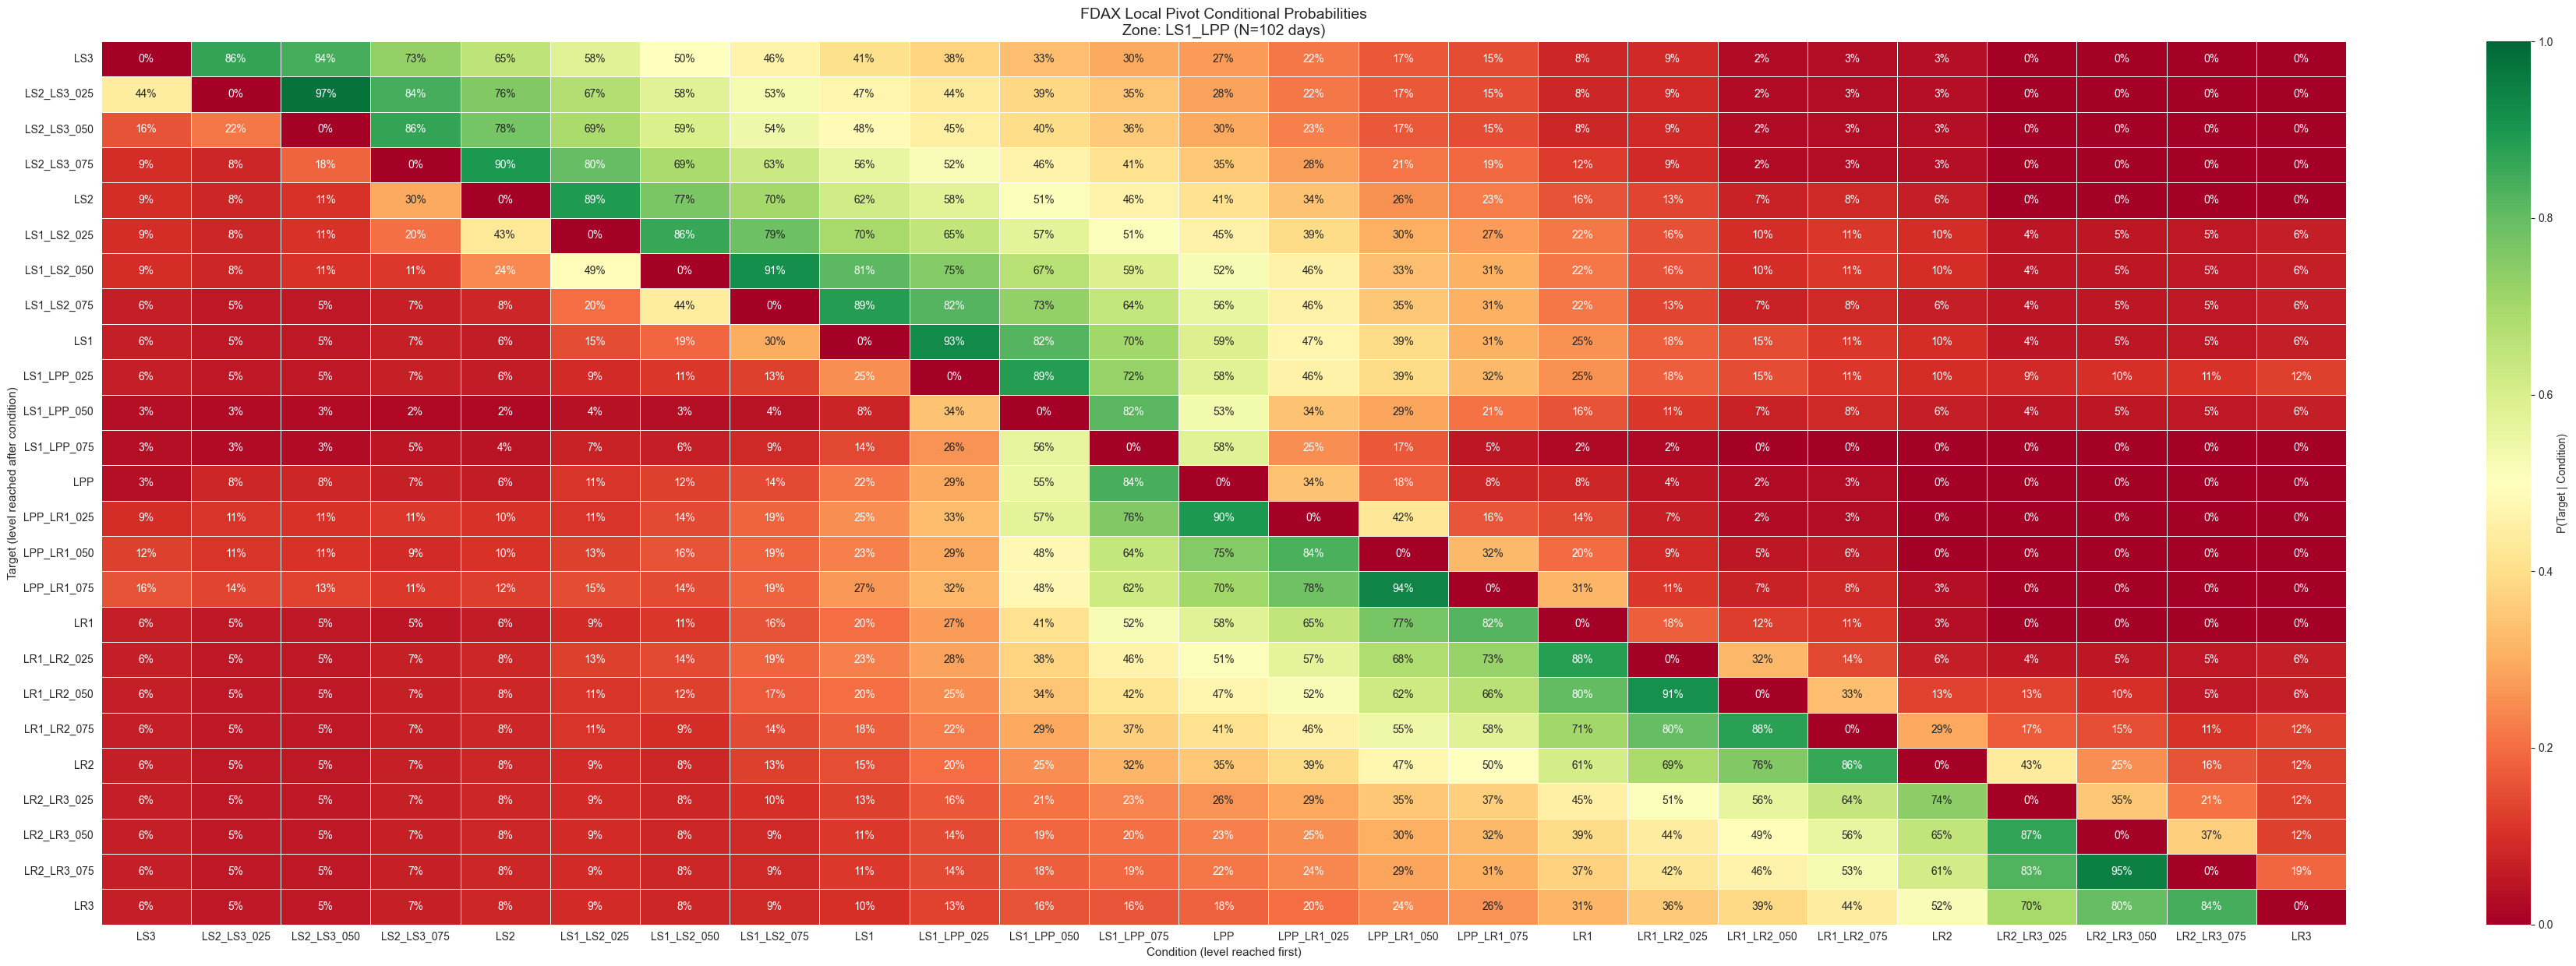

[OK] Heatmap for zone LS1_LPP


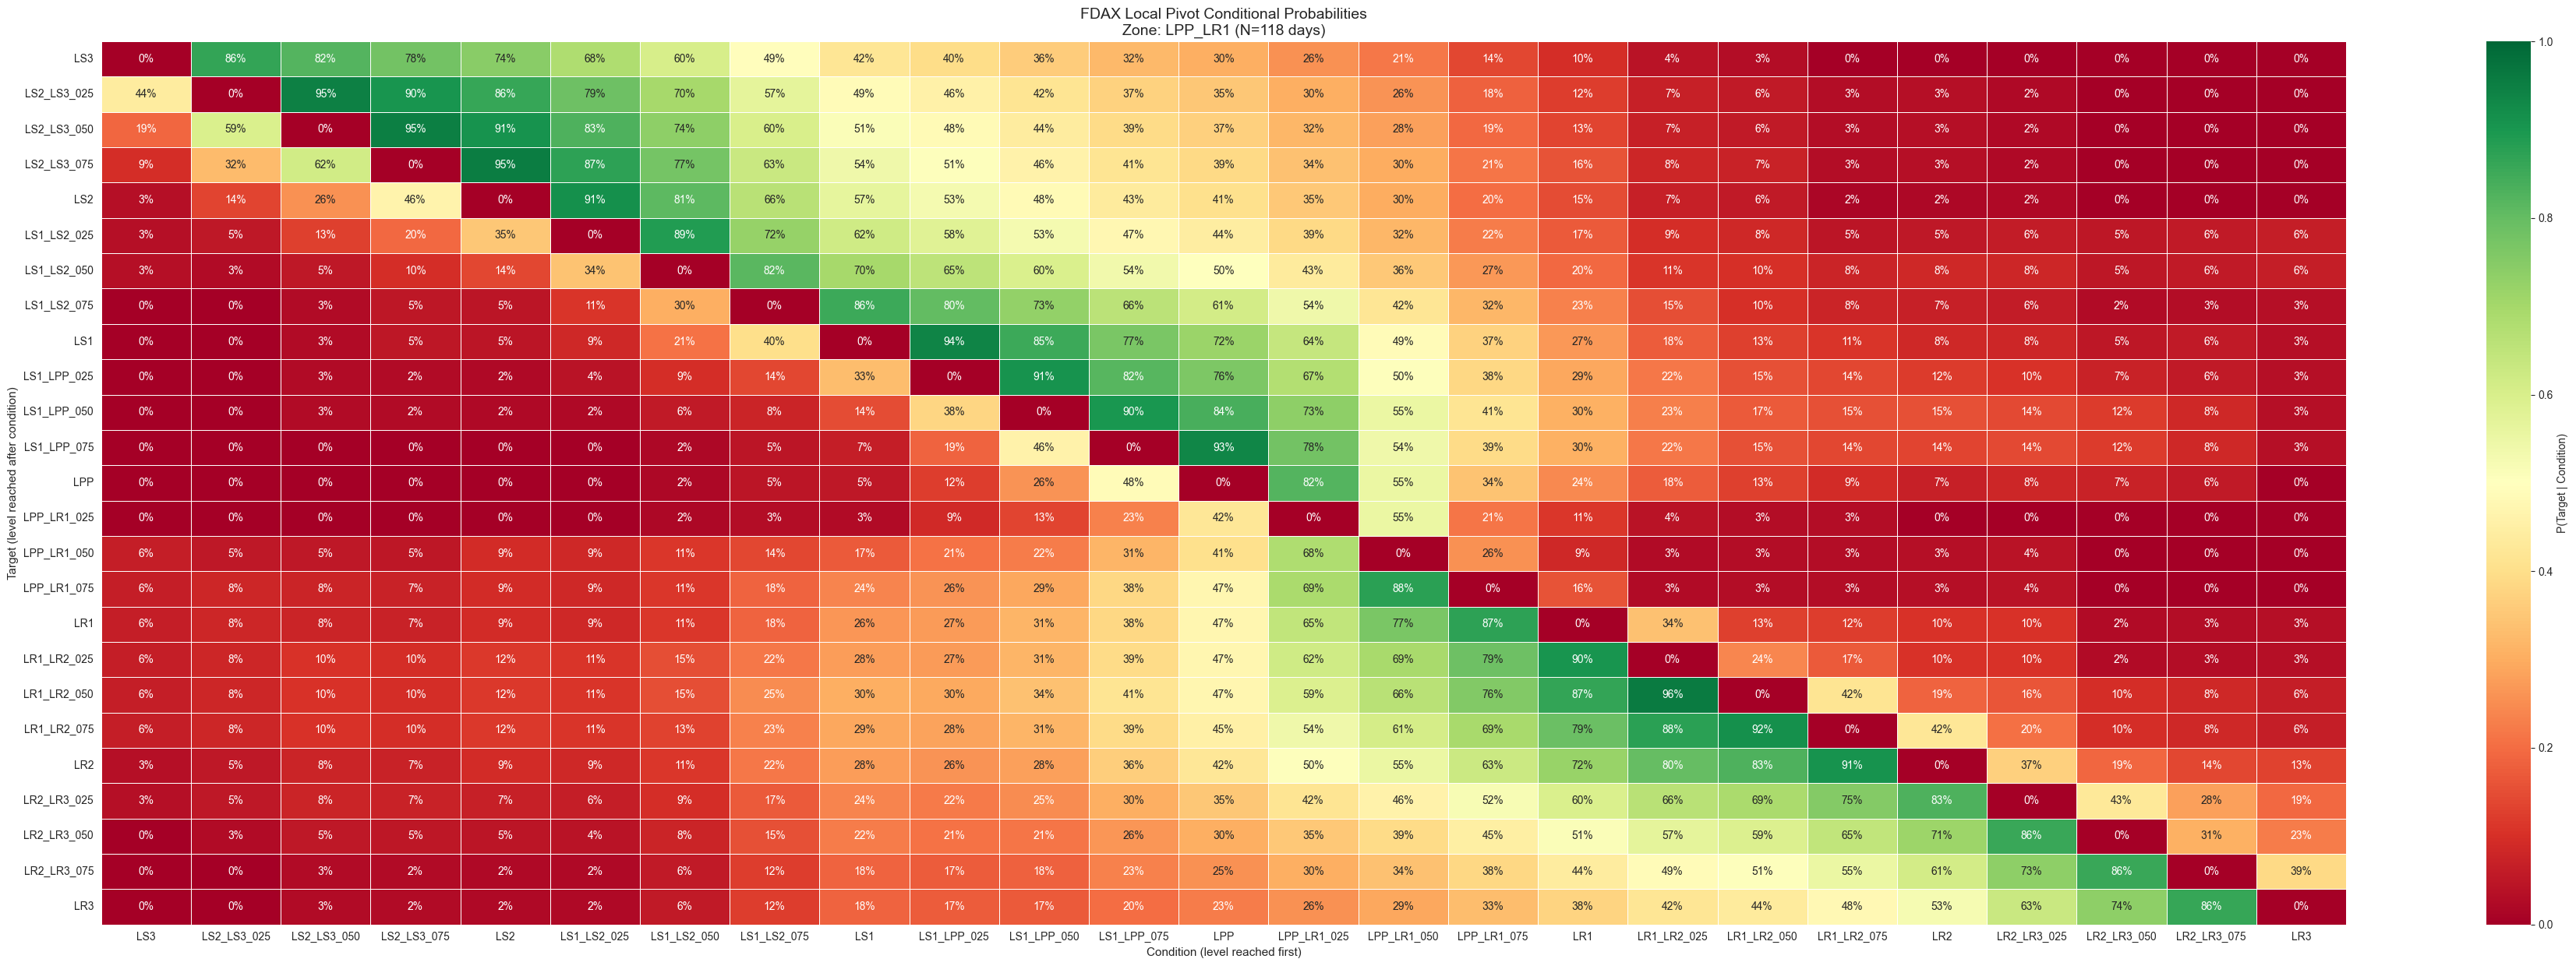

[OK] Heatmap for zone LPP_LR1

[OK] All heatmaps generated


In [9]:
print('\n[STEP 9] Heatmap Visualization')
print('='*80)

for zone, conditions_dict in all_results.items():
    if len(conditions_dict) < 3:
        continue
    
    n_zone = len(df_daily[df_daily['opening_zone'] == zone])
    
    # Build heatmap matrix: rows = targets (spatial order), cols = conditions
    condition_names = list(conditions_dict.keys())
    
    # Only use conditions that are in LEVEL_ORDER for clean ordering
    condition_names_ordered = [c for c in LEVEL_ORDER if c in condition_names]
    
    if len(condition_names_ordered) < 3:
        continue
    
    matrix = pd.DataFrame(index=LEVEL_ORDER, columns=condition_names_ordered, dtype=float)
    
    for cond in condition_names_ordered:
        df_cond = conditions_dict[cond]
        for _, row in df_cond.iterrows():
            if not row['is_condition']:
                matrix.loc[row['target'], cond] = row['prob_conditional']
    
    # Drop rows/cols that are all NaN
    matrix = matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
    matrix = matrix.fillna(0).astype(float)
    
    if matrix.shape[0] < 3 or matrix.shape[1] < 3:
        continue
    
    fig, ax = plt.subplots(figsize=(max(14, len(matrix.columns) * 1.5), max(10, len(matrix.index) * 0.5)))
    
    sns.heatmap(
        matrix,
        annot=True, fmt='.0%', cmap='RdYlGn',
        vmin=0, vmax=1,
        linewidths=0.5, linecolor='white',
        ax=ax,
        cbar_kws={'label': 'P(Target | Condition)'}
    )
    
    ax.set_title(f'FDAX Local Pivot Conditional Probabilities\nZone: {zone} (N={n_zone} days)', fontsize=14)
    ax.set_xlabel('Condition (level reached first)', fontsize=11)
    ax.set_ylabel('Target (level reached after condition)', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    print(f'[OK] Heatmap for zone {zone}')

print('\n[OK] All heatmaps generated')

## Step 10: Export Summary

In [10]:
print('\n[STEP 10] Export Summary')
print('='*80)

export_rows = []

for zone, conditions_dict in all_results.items():
    n_zone = len(df_daily[df_daily['opening_zone'] == zone])
    for condition, df_result in conditions_dict.items():
        n_cond = df_result.loc[df_result['is_condition'], 'n_sequential'].values[0]
        for _, row in df_result.iterrows():
            if row['is_condition']:
                continue
            export_rows.append({
                'zone': zone,
                'n_zone': n_zone,
                'condition': condition,
                'n_condition': n_cond,
                'target': row['target'],
                'prob_conditional': row['prob_conditional'],
                'prob_unconditional': row['prob_unconditional'],
                'prob_delta': row['prob_delta'],
                'n_sequential': row['n_sequential'],
            })

if len(export_rows) > 0:
    df_export = pd.DataFrame(export_rows)
    
    print(f'[OK] Full summary: {len(df_export)} rows')
    print(f'     Zones analyzed: {df_export["zone"].nunique()}')
    print(f'     Unique conditions: {df_export["condition"].nunique()}')
    
    print(f'\n--- Top 25 by DELTA (condition adds most info vs unconditional) ---')
    top_delta = df_export.nlargest(25, 'prob_delta')
    print(top_delta[['zone', 'condition', 'target', 'prob_conditional', 'prob_unconditional', 'prob_delta', 'n_sequential']].to_string(index=False))
    
    print(f'\n--- Top 25 by CONDITIONAL PROBABILITY (highest absolute) ---')
    top_cp = df_export[(df_export['prob_conditional'] < 1.0)].nlargest(25, 'prob_conditional')
    print(top_cp[['zone', 'condition', 'target', 'prob_conditional', 'n_condition', 'n_sequential']].to_string(index=False))
    
    print(f'\n--- Lowest conditional probabilities (strong barriers / rarely breached) ---')
    low_cp = df_export[(df_export['prob_conditional'] > 0) & (df_export['prob_conditional'] < 0.15) & (df_export['n_condition'] >= 10)]
    low_cp = low_cp.nsmallest(25, 'prob_conditional')
    if len(low_cp) > 0:
        print(low_cp[['zone', 'condition', 'target', 'prob_conditional', 'n_condition', 'n_sequential']].to_string(index=False))
    else:
        print('  [No targets with <15% and sufficient N]')
else:
    print('[WARNING] No results to export')

print('\n[COMPLETE] FDAX Local Pivot Conditional Probabilities v2 (Full Range)')
print('='*80)


[STEP 10] Export Summary
[OK] Full summary: 1200 rows
     Zones analyzed: 2
     Unique conditions: 25

--- Top 25 by DELTA (condition adds most info vs unconditional) ---
   zone   condition      target  prob_conditional  prob_unconditional  prob_delta  n_sequential
LS1_LPP LR2_LR3_050 LR2_LR3_075          0.950000            0.186275    0.763725            19
LS1_LPP LR2_LR3_075         LR3          0.842105            0.156863    0.685243            16
LS1_LPP LR2_LR3_025 LR2_LR3_050          0.869565            0.196078    0.673487            20
LS1_LPP LR2_LR3_050         LR3          0.800000            0.156863    0.643137            16
LS1_LPP LR2_LR3_025 LR2_LR3_075          0.826087            0.186275    0.639812            19
LPP_LR1 LS2_LS3_050 LS2_LS3_025          0.948718            0.313559    0.635159            37
LPP_LR1 LS2_LS3_075 LS2_LS3_050          0.951220            0.330508    0.620711            39
LS1_LPP LS2_LS3_050 LS2_LS3_025          0.973684         

## Step 11: Summary

**How to read the results:**

The output table for each zone/condition reads top-to-bottom as **low price to high price** (LS3 at top, LR3 at bottom).

- **Cond.P** (Conditional Probability): Given we reached the condition level, what % of the time did we also reach this target AFTER?
- **Uncond.P** (Unconditional Probability): What % of days in this zone reach this target regardless of condition?
- **Delta**: Cond.P minus Uncond.P. Positive = condition adds information (reaching condition makes target more likely).
- **N**: How many days the sequential condition-then-target occurred.
- **Bar**: Visual representation of conditional probability.

**Look for:**
- High conditional probabilities (>75%) = strong continuation/reversion patterns
- Large positive deltas (>20%) = condition is highly informative
- Low probabilities (<15%) with good N = strong barriers that rarely get breached
- Asymmetry: up targets vs down targets from same condition having very different probabilities